
--- TRAIN METRICS ---
RMSE  : 337.6149
MAE   : 198.5081
Median AE : 105.7455
R²    : 0.9771
Explained Variance : 0.9771
Max Error : 3634.3884
MAPE (%)  : 4.47
sMAPE (%) : 4.37
MSLE      : 0.0063038198967973885


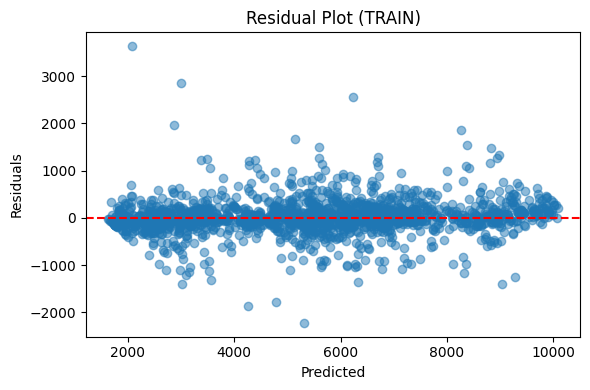


--- VALIDATION METRICS ---
RMSE  : 545.9689
MAE   : 336.0047
Median AE : 170.3734
R²    : 0.8443
Explained Variance : 0.8526
Max Error : 2842.8716
MAPE (%)  : 7.94
sMAPE (%) : 8.15
MSLE      : 0.01813614938250642


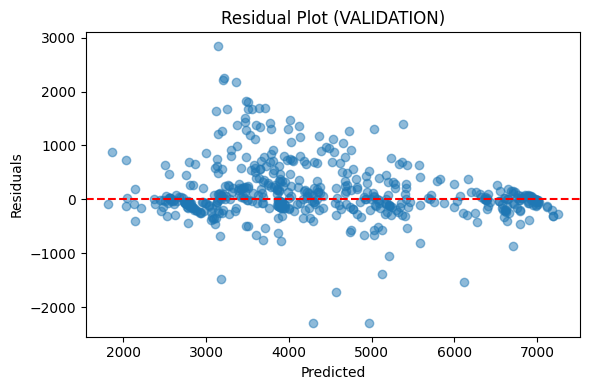


--- TEST METRICS ---
RMSE  : 509.0829
MAE   : 335.0785
Median AE : 226.0505
R²    : 0.9635
Explained Variance : 0.9635
Max Error : 4134.8653
MAPE (%)  : 7.58
sMAPE (%) : 7.38
MSLE      : 0.011861326144345437


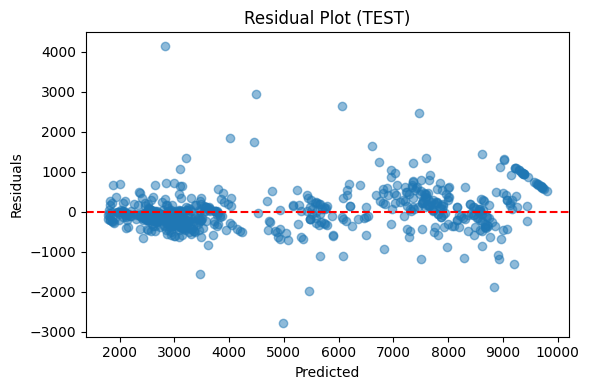

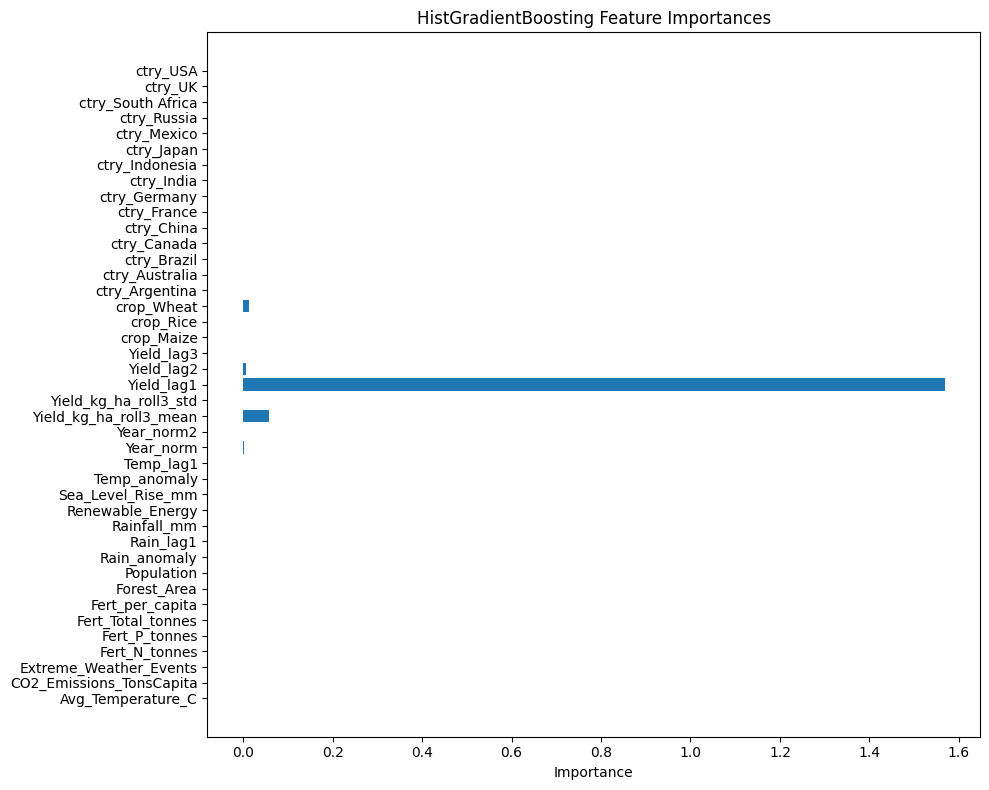

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, r2_score, explained_variance_score, 
    median_absolute_error, max_error, mean_squared_log_error
)
import joblib

# ================================
# STEP 0: LOAD DATA
# ================================
df = pd.read_csv("data/cleaned/final_cleaned_dataset.csv")

# ================================
# STEP 1: TARGET & FEATURES
# ================================
target_candidates = [col for col in df.columns if "yield" in col.lower()]
if not target_candidates:
    raise ValueError("No column with 'yield' found in dataset!")
target = target_candidates[0]

exclude_cols = ["Country", "Year"]
features = list(df.columns.difference(exclude_cols + [target]))
X = df[features]
y = df[target]

# ================================
# STEP 2: SPLIT DATA
# ================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, shuffle=False
)

# ================================
# STEP 3: SCALE FEATURES
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler_hgb.pkl")

# ================================
# STEP 4: TRAIN HISTGRADIENTBOOSTING
# ================================
hgb = HistGradientBoostingRegressor(
    max_iter=300,
    max_depth=6,
    learning_rate=0.05,
    min_samples_leaf=5,
    early_stopping=True,        # enable early stopping
    validation_fraction=0.2,    # fraction of training data for validation
    n_iter_no_change=20,
    random_state=42
)

hgb.fit(X_train_scaled, y_train)  # internal validation for early stopping
joblib.dump(hgb, "models/hgb_model.pkl")

# ================================
# STEP 5: METRICS FUNCTION
# ================================
def regression_metrics(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae  = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    ev   = explained_variance_score(y_true, y_pred)
    maxerr = max_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    msle = mean_squared_log_error(y_true, y_pred) if (y_true >= 0).all() and (y_pred >= 0).all() else np.nan

    print(f"\n--- {name} METRICS ---")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"Median AE : {medae:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"Explained Variance : {ev:.4f}")
    print(f"Max Error : {maxerr:.4f}")
    print(f"MAPE (%)  : {mape:.2f}")
    print(f"sMAPE (%) : {smape:.2f}")
    print(f"MSLE      : {msle}")

    # Residual plot
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({name})")
    plt.tight_layout()
    plt.show()

# ================================
# STEP 6: PREDICTIONS
# ================================
y_pred_train = hgb.predict(X_train_scaled)
y_pred_val   = hgb.predict(X_val_scaled)
y_pred_test  = hgb.predict(X_test_scaled)

# ================================
# STEP 7: EVALUATE
# ================================
regression_metrics(y_train, y_pred_train, "TRAIN")
regression_metrics(y_val, y_pred_val, "VALIDATION")
regression_metrics(y_test, y_pred_test, "TEST")

# ================================
# ================================
# STEP 8: FEATURE IMPORTANCES (FIXED)
# ================================
try:
    feat_importances = hgb.feature_importances_
except AttributeError:
    # fallback using permutation importance
    from sklearn.inspection import permutation_importance
    result = permutation_importance(hgb, X_test_scaled, y_test, n_repeats=10, random_state=42)
    feat_importances = result.importances_mean

plt.figure(figsize=(10, 8))
plt.barh(features, feat_importances)
plt.xlabel("Importance")
plt.title("HistGradientBoosting Feature Importances")
plt.tight_layout()
plt.show()

# ================================
# STEP 9: PER-CROP PERFORMANCE
# ================================
if "Crop" in df.columns:
    crops = df.loc[X_test.index, "Crop"].unique()
    print("\n=== PER-CROP PERFORMANCE ===")
    for crop in crops:
        idx = df.loc[X_test.index, "Crop"] == crop
        y_true_crop = y_test[idx]
        y_pred_crop = y_pred_test[idx]
        if len(y_true_crop) > 0:
            rmse_crop = np.sqrt(np.mean((y_true_crop - y_pred_crop) ** 2))
            r2_crop = r2_score(y_true_crop, y_pred_crop)
            print(f"{crop:10}: R² = {r2_crop:.4f}, RMSE = {rmse_crop:.2f}, n = {len(y_true_crop)}")